# 🏡 House Price Prediction Project

## 1. Introduction
# 🏡 Project Portfolio Lab: Predicting House Prices (Multiple Linear Regression, Ridge & LASSO)

**Dataset:** `house_prices_portfolio.csv`    
**Goal:** Build and understand linear models to predict house prices.

## 🎯 Problem Statement
A real-estate analytics team wants to estimate **house prices** in a city using property and neighborhood features. Your task is to:
1. Explore the dataset and understand the relationships.
2. Build a **Multiple Linear Regression** model and interpret results.
3. Validate **assumptions** (linearity, independence, homoscedasticity, normality, multicollinearity, outliers).
4. Apply **variable selection** and **regularization** (Ridge/LASSO) to improve generalization.
5. **Persist** the best-performing model (save & load) for future use.

> This PPL mimics the workflow you'd follow in a real project and is perfect for your portfolio.


## 3. What you'll learn
- Load and explore a dataset (EDA)  
- Build a **Multiple Linear Regression** model (`LinearRegression`)  
- Check basic assumptions with simple plots and tests  
- Understand **overfitting vs. generalization** (train vs. test performance)  
- Improve models with **Ridge (L2)** and **LASSO (L1)** regularization  
- **Save** and **load** a trained model using `pickle`

In [1]:

# === Setup ===
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling & evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, minmax_scale

# Inference & diagnostics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad
# from statsmodels.stats.stattools import durbin_watson

# Persistence
import pickle
import joblib

# Utilities
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Re-import all necessary libraries as the setup cell might not have been executed.
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling & evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, minmax_scale

# Inference & diagnostics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Persistence
import pickle
import joblib

# Utilities
import warnings
warnings.filterwarnings("ignore")

In [55]:
df = pd.read_csv("house_prices_portfolio.csv")

df.head()

,House_Price,Lot_Size,Bedrooms,Bathrooms,House_Age,Distance_to_CityCenter,Crime_Rate,Nearby_Schools,Monthly_Income,Renovated,Energy_Efficiency_Score,Garden_Size,Noise_Level
0,89.96,2000,3,3,45,8.25,70.22,6,4158.35,0,56.29,125.1,8.38
1,9.92,1256,2,2,45,23.82,68.95,7,5658.32,1,80.23,136.6,3.99
2,175.77,2000,7,5,38,3.45,72.10,8,4652.73,0,60.33,375.4,8.45
3,57.77,2000,2,2,35,7.27,93.98,4,2381.04,0,44.46,308.8,8.45
4,74.11,913,3,3,7,8.87,89.90,6,2527.46,1,50.01,260.5,7.66


## 4. Data Understanding and Exploratory Data Analysis (EDA)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   House_Price              500 non-null    float64
 1   Lot_Size                 500 non-null    int64  
 2   Bedrooms                 500 non-null    int64  
 3   Bathrooms                500 non-null    int64  
 4   House_Age                500 non-null    int64  
 5   Distance_to_CityCenter   500 non-null    float64
 6   Crime_Rate               500 non-null    float64
 7   Nearby_Schools           500 non-null    int64  
 8   Monthly_Income           500 non-null    float64
 9   Renovated                500 non-null    int64  
 10  Energy_Efficiency_Score  500 non-null    float64
 11  Garden_Size              500 non-null    float64
 12  Noise_Level              500 non-null    float64
dtypes: float64(7), int64(6)
memory usage: 50.9 KB


In [6]:
df.shape

(500, 13)

📌 **Insight:** The dataset contains 500 entries and 13 columns. There are no missing values, and the data types are appropriate for analysis (float64 for numerical, int64 for categorical/count-based features like Bedrooms, Bathrooms, Renovated).

In [7]:
df.describe()

,House_Price,Lot_Size,Bedrooms,Bathrooms,House_Age,Distance_to_CityCenter,Crime_Rate,Nearby_Schools,Monthly_Income,Renovated,Energy_Efficiency_Score,Garden_Size,Noise_Level
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,98.989480,1690.904000,3.974000,3.060000,33.888000,8.942380,70.799160,6.670000,4514.206400,0.292000,61.379300,253.347200,8.217620
std,44.772335,342.192294,1.631763,1.584115,19.538346,5.910477,13.476801,2.105699,1492.544152,0.455138,12.059863,114.968455,1.529183
min,-41.290000,736.000000,1.000000,1.000000,0.000000,1.420000,25.320000,2.000000,1500.000000,0.000000,31.690000,14.000000,0.010000
25%,69.665000,1431.500000,3.000000,2.000000,17.000000,5.017500,61.790000,5.000000,3409.370000,0.000000,52.910000,159.875000,7.555000
50%,99.385000,1810.000000,4.000000,3.000000,34.000000,7.460000,71.085000,7.000000,4510.395000,0.000000,60.705000,245.950000,8.465000
75%,129.342500,2000.000000,5.000000,4.000000,50.000000,11.160000,81.185000,8.000000,5487.370000,1.000000,69.462500,335.850000,9.272500
max,334.620000,2000.000000,7.000000,6.000000,69.000000,40.000000,95.000000,14.000000,8767.940000,1.000000,96.990000,548.100000,10.000000


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
House_Price,500.0,98.98948,44.772335,-41.29,69.6650,99.385,129.3425,334.62
Lot_Size,500.0,1690.90400,342.192294,736.00,1431.5000,1810.000,2000.0000,2000.00
Bedrooms,500.0,3.97400,1.631763,1.00,3.0000,4.000,5.0000,7.00
Bathrooms,500.0,3.06000,1.584115,1.00,2.0000,3.000,4.0000,6.00
House_Age,500.0,33.88800,19.538346,0.00,17.0000,34.000,50.0000,69.00
Distance_to_CityCenter,500.0,8.94238,5.910477,1.42,5.0175,7.460,11.1600,40.00
Crime_Rate,500.0,70.79916,13.476801,25.32,61.7900,71.085,81.1850,95.00
Nearby_Schools,500.0,6.67000,2.105699,2.00,5.0000,7.000,8.0000,14.00
Monthly_Income,500.0,4514.20640,1492.544152,1500.00,3409.3700,4510.395,5487.3700,8767.94
Renovated,500.0,0.29200,0.455138,0.00,0.0000,0.000,1.0000,1.00


📌 **Insight:** The summary statistics reveal a wide range for `House_Price` (from -41.29 to 334.62, which includes an anomalous negative value, suggesting potential outliers or data entry errors that may need further investigation). Key features like `Lot_Size`, `House_Age`, `Distance_to_CityCenter`, `Crime_Rate`, and `Monthly_Income` also show considerable variability, indicating diverse property characteristics within the dataset. `Renovated` is a binary variable with a mean of 0.29, implying about 29% of houses are renovated.

In [9]:
# Correlation

corr = df.corr()['House_Price'].sort_values()
corr

,House_Price
Crime_Rate,-0.490324
Distance_to_CityCenter,-0.409821
House_Age,-0.272099
Renovated,0.135616
Garden_Size,0.144462
Lot_Size,0.179512
Noise_Level,0.325410
Energy_Efficiency_Score,0.350907
Monthly_Income,0.384082
Nearby_Schools,0.403098


📌 **Insight:** The correlation analysis with `House_Price` reveals several strong relationships:
- `Bedrooms` and `Bathrooms` show strong positive correlations (0.526 and 0.493 respectively), as expected.
- `Crime_Rate` and `Distance_to_CityCenter` have strong negative correlations (-0.490 and -0.410), indicating that higher crime rates and greater distances from the city center are associated with lower house prices.
- `House_Age` has a moderate negative correlation (-0.272), suggesting older homes tend to be less expensive.
- `Monthly_Income` and `Nearby_Schools` show moderate positive correlations (0.384 and 0.403), aligning with typical market dynamics.

In [10]:
corr = df.corr()
corr

,House_Price,Lot_Size,Bedrooms,Bathrooms,House_Age,Distance_to_CityCenter,Crime_Rate,Nearby_Schools,Monthly_Income,Renovated,Energy_Efficiency_Score,Garden_Size,Noise_Level
House_Price,1.000000,0.179512,0.525954,0.492771,-0.272099,-0.409821,-0.490324,0.403098,0.384082,0.135616,0.350907,0.144462,0.325410
Lot_Size,0.179512,1.000000,0.063571,0.030610,0.053722,0.019590,0.056230,-0.080179,-0.051788,-0.017036,-0.065431,0.456832,-0.045337
Bedrooms,0.525954,0.063571,1.000000,0.884418,0.022977,0.007983,-0.069296,0.079151,0.076328,-0.011344,0.051116,0.033587,-0.029483
Bathrooms,0.492771,0.030610,0.884418,1.000000,0.021002,0.021335,-0.052858,0.058216,0.073688,-0.007671,0.048782,0.010777,-0.049570
House_Age,-0.272099,0.053722,0.022977,0.021002,1.000000,0.145725,0.077111,-0.050730,-0.039440,-0.024710,-0.044313,0.066894,-0.112119
Distance_to_CityCenter,-0.409821,0.019590,0.007983,0.021335,0.145725,1.000000,0.328818,-0.254790,0.011865,0.027551,0.001232,-0.024033,-0.883563
Crime_Rate,-0.490324,0.056230,-0.069296,-0.052858,0.077111,0.328818,1.000000,-0.755666,-0.868841,-0.306805,-0.757887,0.041200,-0.284605
Nearby_Schools,0.403098,-0.080179,0.079151,0.058216,-0.050730,-0.254790,-0.755666,1.000000,0.760641,0.295212,0.671172,-0.078793,0.232277
Monthly_Income,0.384082,-0.051788,0.076328,0.073688,-0.039440,0.011865,-0.868841,0.760641,1.000000,0.367611,0.865443,-0.076503,-0.009697
Renovated,0.135616,-0.017036,-0.011344,-0.007671,-0.024710,0.027551,-0.306805,0.295212,0.367611,1.000000,0.564241,0.018364,-0.035251


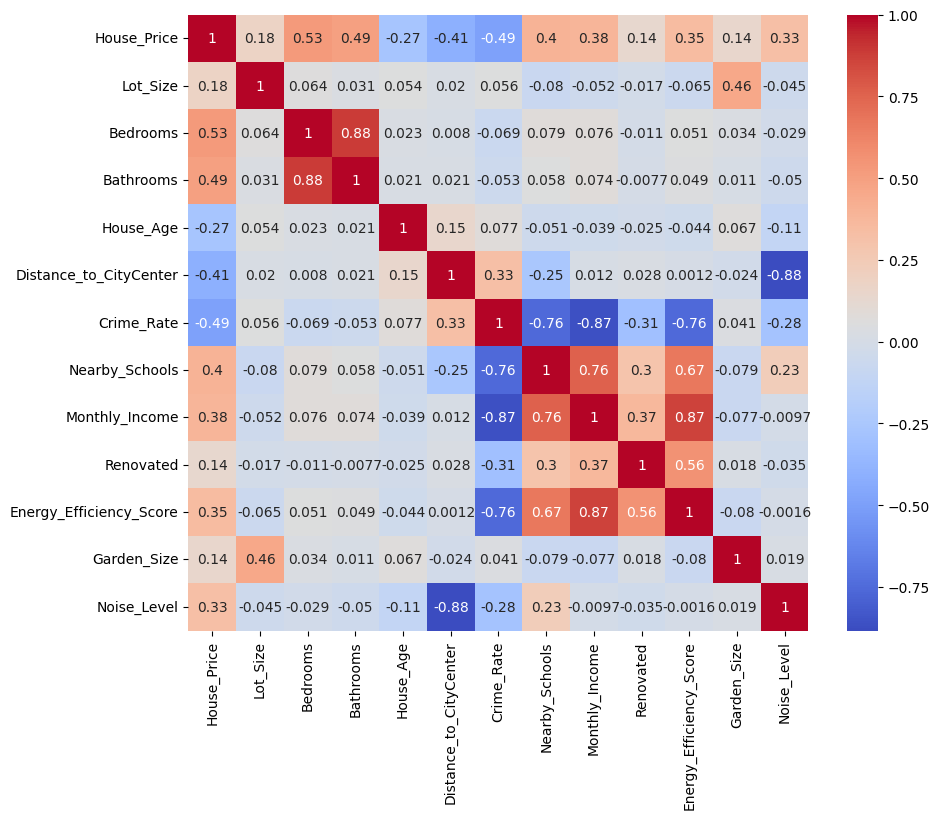

In [11]:
plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [12]:
df.head(1)

,House_Price,Lot_Size,Bedrooms,Bathrooms,House_Age,Distance_to_CityCenter,Crime_Rate,Nearby_Schools,Monthly_Income,Renovated,Energy_Efficiency_Score,Garden_Size,Noise_Level
0,89.96,2000,3,3,45,8.25,70.22,6,4158.35,0,56.29,125.1,8.38


## 5. Data Preprocessing: Train/Test Split

In [13]:
X = df.drop(columns=['House_Price'])
y = df['House_Price']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train.shape

(400, 12)

## 6. Model Building: Baseline Multiple Linear Regression (Scikit-learn)

In [16]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [17]:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

In [18]:
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = root_mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = root_mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

In [19]:
print(f"Train MSE: {mse_train:.3f} | Test MSE: {mse_test:.3f}")
print(f"Train RMSE: {rmse_train:.3f} | Test RMSE: {rmse_test:.3f}")
print(f"Train R2_Score: {r2_train:.3f} | Test R2_Score: {r2_test:.3f}")

Train MSE: 630.247 | Test MSE: 818.373
Train RMSE: 25.105 | Test RMSE: 28.607
Train R2_Score: 0.694 | Test R2_Score: 0.533


## 7. Model Diagnostics: OLS with Statsmodels (Coefficients, P-value)

In [20]:
X_train_const = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_const).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            House_Price   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     73.03
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.50e-91
Time:                        19:20:52   Log-Likelihood:                -1856.8
No. Observations:                 400   AIC:                             3740.
Df Residuals:                     387   BIC:                             3791.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      42.3895     33.988      1.247      0.213     -24.435     109.214
Lot_Size                    0.0184      0.004      4.326      0.000       0.010       0.027
Bedrooms                    8.3121      1.707      4.870      0.000       4.956      11.668
Bathrooms                   5.8201      1.767      3.294      0.001       2.346       9.294
House_Age                  -0.5409      0.066     -8.168      0.000      -0.671      -0.411
Distance_to_CityCenter     -3.1276      0.516     -6.059      0.000      -4.143      -2.113
Crime_Rate                 -0.3959      0.268     -1.475      0.141      -0.924       0.132
Nearby_Schools              0.0559      1.029      0.054      0.957      -1.967       2.079
Monthly_Income              0.0033      0.003      1.121      0.263      -0.003       0.009
Renovated                  -2.2102      3.633     -0.608      0.543      -9.353       4.932
Energy_Efficiency_Score     0.6715      0.265      2.529      0.012       0.150       1.193
Garden_Size                 0.0442      0.013      3.490      0.001       0.019       0.069
Noise_Level                -2.2623      1.753     -1.290      0.198      -5.709       1.184
==============================================================================
Omnibus:                      104.577   Durbin-Watson:                   2.100
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              695.206
Skew:                           0.924   Prob(JB):                    1.09e-151
Kurtosis:                       9.189   Cond. No.                     1.37e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.37e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Multicollinearity Check (VIF)

In [21]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_const.values, i) for i in range(len(X_train_const.columns))]

print("Variance Inflation Factor (VIF):")
print(vif_data.sort_values(by='VIF', ascending=False))

Variance Inflation Factor (VIF):
                    feature         VIF
0                     const  709.349626
8            Monthly_Income   12.201237
6                Crime_Rate    8.443622
10  Energy_Efficiency_Score    6.154324
5    Distance_to_CityCenter    5.925584
2                  Bedrooms    4.946052
3                 Bathrooms    4.938406
12              Noise_Level    4.518729
7            Nearby_Schools    3.002440
9                 Renovated    1.701809
11              Garden_Size    1.327716
1                  Lot_Size    1.319202
4                 House_Age    1.038410


> A high VIF (typically > 5 or > 10) indicates high multicollinearity. We observe high VIF for 'Monthly_Income', 'Crime_Rate', 'Energy_Efficiency_Score', and 'Nearby_Schools', which aligns with the warning from the OLS summary. This suggests these variables are highly correlated with each other, which can make it difficult to interpret individual coefficients. Regularization methods like Ridge and Lasso can help mitigate issues caused by multicollinearity.

## 8. Assumption Testing

In [22]:
fitted = y_train_pred
residuals = y_train - fitted

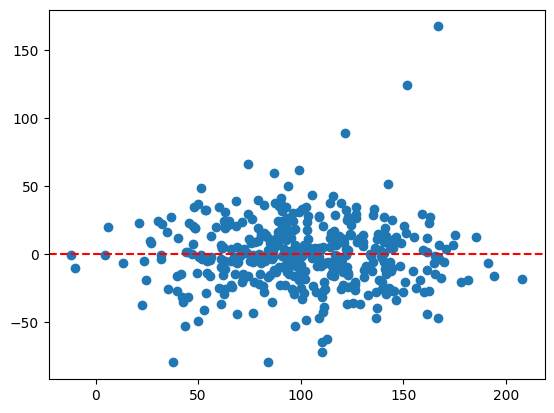

In [23]:
plt.scatter(fitted, residuals)
plt.axhline(0, linestyle='--', c='red')
plt.show()

### Normality of Residuals

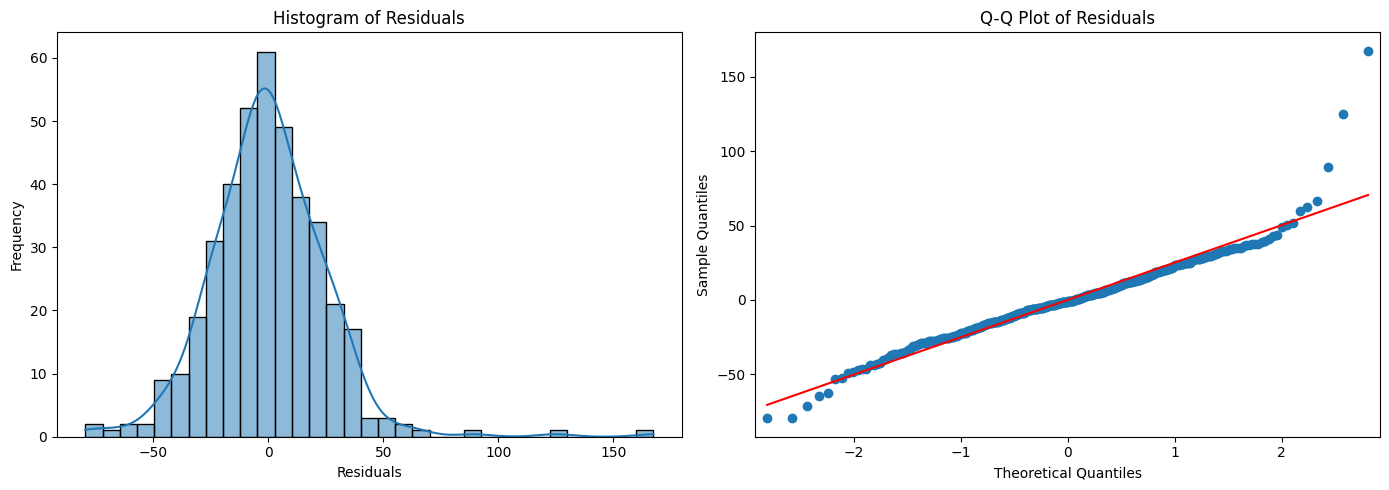

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of Residuals
sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title('Histogram of Residuals')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

# Q-Q Plot of Residuals
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

> The histogram shows that the residuals are somewhat skewed to the right and do not perfectly follow a normal distribution. The Q-Q plot deviates significantly from the straight line, especially at the tails, indicating a departure from normality. This violation of the normality assumption for residuals might affect the reliability of p-values and confidence intervals, though the model itself might still be useful for prediction.

### Homoscedasticity Check (Residuals vs. Fitted Values Plot)

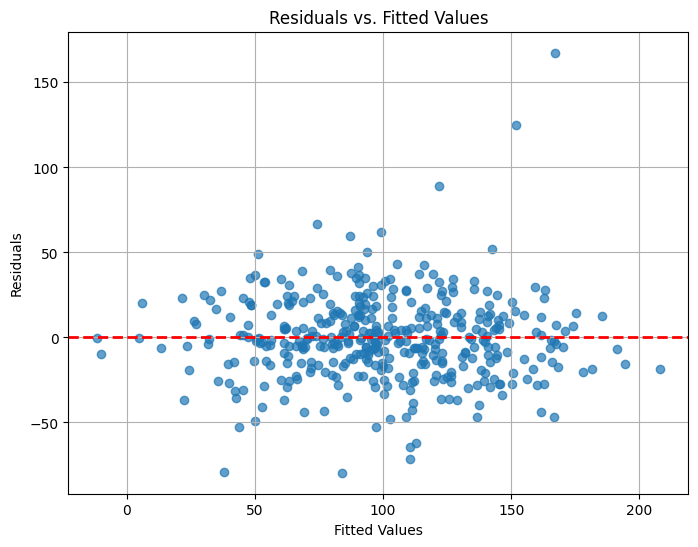

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(fitted, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

> The residuals vs. fitted values plot shows a somewhat cone-shaped pattern, particularly at higher fitted values, where the spread of residuals tends to increase. This suggests the presence of heteroscedasticity, meaning the variance of the errors is not constant across all levels of the independent variables. This violates a key assumption of OLS and can lead to inefficient coefficient estimates and incorrect standard errors.

### Predicted vs. Actual Values Plot

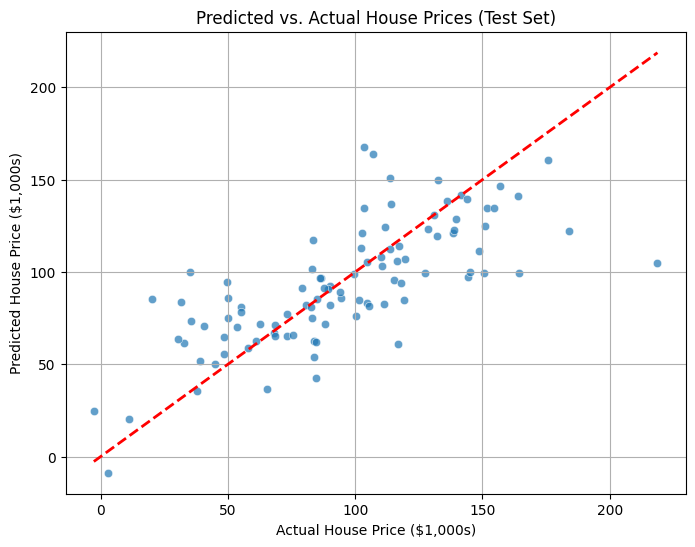

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Line for perfect prediction
plt.title('Predicted vs. Actual House Prices (Test Set)')
plt.xlabel('Actual House Price ($1,000s)')
plt.ylabel('Predicted House Price ($1,000s)')
plt.grid(True)
plt.show()

📌 **Insight:** The predicted vs. actual values plot shows that the model generally captures the trend of house prices, with predictions clustering around the ideal `y=x` line. However, there's a noticeable spread, especially for higher actual prices, indicating that the model struggles to accurately predict the most expensive homes. There are also some predictions that are negative, which is unrealistic for house prices and suggests potential limitations or outliers in the data/model.

## 9. Regularization: Ridge & LASSO

In [27]:
# Scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# Fit with RIdge and Lassor

ridge = Ridge(alpha=0.8, random_state=42)
lasso = Lasso(alpha=0.0001, random_state=42, max_iter=100000)

ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

In [29]:
print("Ridge Train R2:", r2_score(y_train, ridge_train_pred))
print("Ridge Test R2:", r2_score(y_test, ridge_test_pred))
print("\nLasso Train R2:", r2_score(y_train, lasso_train_pred))
print("Lasso Test R2:", r2_score(y_test, lasso_test_pred))

Ridge Train R2: 0.6936601335498116
Ridge Test R2: 0.5337120073425465

Lasso Train R2: 0.6936659818816076
Lasso Test R2: 0.5334738544083213


In [32]:
import pandas as pd
from sklearn.metrics import mean_absolute_error

# Calculate MAE for Linear Regression
mae_train_lr = mean_absolute_error(y_train, y_train_pred)
mae_test_lr = mean_absolute_error(y_test, y_test_pred)

# Calculate MAE for Ridge
mae_train_ridge = mean_absolute_error(y_train, ridge_train_pred)
mae_test_ridge = mean_absolute_error(y_test, ridge_test_pred)

# Calculate MAE for Lasso
mae_train_lasso = mean_absolute_error(y_train, lasso_train_pred)
mae_test_lasso = mean_absolute_error(y_test, lasso_test_pred)

# Create a DataFrame for MAE results
mae_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'Train MAE': [mae_train_lr, mae_train_ridge, mae_train_lasso],
    'Test MAE': [mae_test_lr, mae_test_ridge, mae_test_lasso]
})

print("--- Mean Absolute Error (MAE) ---")
display(mae_results)

--- Mean Absolute Error (MAE) ---


,Model,Train MAE,Test MAE
0,Linear Regression,18.197729,20.899425
1,Ridge,18.194523,20.893281
2,Lasso,18.197694,20.899428


In [33]:
ridge_coefs = pd.Series(ridge.coef_, index=X_train.columns).sort_values()
lasso_coefs = pd.Series(lasso.coef_, index=X_train.columns).sort_values()

print("Ridge Coefficients:")
print(ridge_coefs)
print("\nLasso Coefficients:")
print(lasso_coefs)

Ridge Coefficients:
Distance_to_CityCenter    -18.583389
House_Age                 -10.608342
Crime_Rate                 -5.576840
Noise_Level                -3.323040
Renovated                  -0.986612
Nearby_Schools              0.160780
Monthly_Income              4.905334
Garden_Size                 5.115758
Lot_Size                    6.344788
Energy_Efficiency_Score     7.946021
Bathrooms                   9.379367
Bedrooms                   13.763077
dtype: float64

Lasso Coefficients:
Distance_to_CityCenter    -18.820791
House_Age                 -10.621666
Crime_Rate                 -5.468262
Noise_Level                -3.499901
Renovated                  -1.012565
Nearby_Schools              0.120119
Monthly_Income              4.997052
Garden_Size                 5.132048
Lot_Size                    6.341321
Energy_Efficiency_Score     8.007071
Bathrooms                   9.340824
Bedrooms                   13.821420
dtype: float64


### Visualizing Model Coefficients

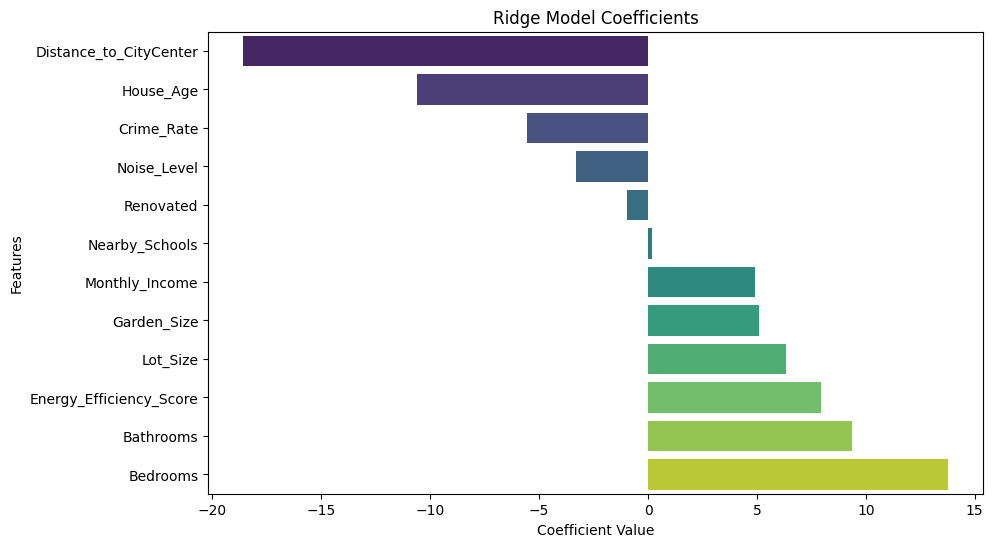

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(x=ridge_coefs.values, y=ridge_coefs.index, palette='viridis')
plt.title('Ridge Model Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

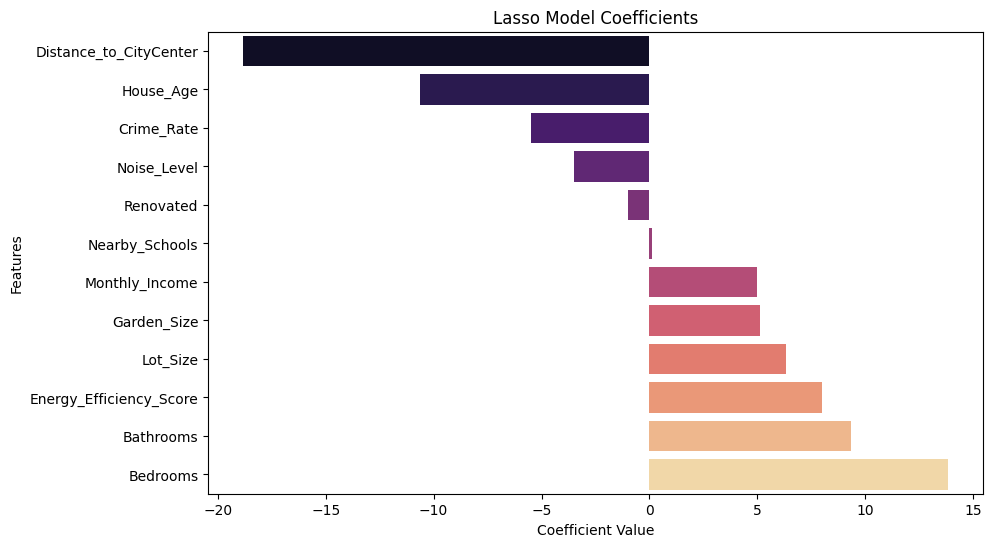

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x=lasso_coefs.values, y=lasso_coefs.index, palette='magma')
plt.title('Lasso Model Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

## 10. Model Persistence (Save & Load)

In [36]:
# Save the best model (Ridge) and the scaler
joblib.dump(ridge, 'ridge_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Ridge model and scaler saved successfully!")

Ridge model and scaler saved successfully!


In [37]:
# Load the model and scaler
loaded_ridge_model = joblib.load('ridge_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

print("Ridge model and scaler loaded successfully!")

Ridge model and scaler loaded successfully!


In [38]:
# Make a prediction with the loaded model and scaler (example)
# Let's use a sample from X_test and scale it
sample_data = X_test.iloc[0:1]
sample_data_scaled = loaded_scaler.transform(sample_data)

# Predict using the loaded model
predicted_price = loaded_ridge_model.predict(sample_data_scaled)

print(f"Sample actual house price: {y_test.iloc[0]:.2f}")
print(f"Sample predicted house price (loaded model): {predicted_price[0]:.2f}")

Sample actual house price: 164.40
Sample predicted house price (loaded model): 99.32


In [39]:
# Save the best model (Ridge) and the scaler
joblib.dump(ridge, 'ridge_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Ridge model and scaler saved successfully!")

Ridge model and scaler saved successfully!


In [40]:
# Load the model and scaler
loaded_ridge_model = joblib.load('ridge_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

print("Ridge model and scaler loaded successfully!")

Ridge model and scaler loaded successfully!


In [41]:
# Make a prediction with the loaded model and scaler (example)
# Let's use a sample from X_test and scale it
sample_data = X_test.iloc[0:1]
sample_data_scaled = loaded_scaler.transform(sample_data)

# Predict using the loaded model
predicted_price = loaded_ridge_model.predict(sample_data_scaled)

print(f"Sample actual house price: {y_test.iloc[0]:.2f}")
print(f"Sample predicted house price (loaded model): {predicted_price[0]:.2f}")

Sample actual house price: 164.40
Sample predicted house price (loaded model): 99.32


In [42]:
# Predict house prices for a larger sample from X_test

# Let's take the first 5 samples from X_test
sample_data_multiple = X_test.iloc[0:5]
sample_actual_prices = y_test.iloc[0:5]

# Scale the multiple samples using the loaded scaler
sample_data_multiple_scaled = loaded_scaler.transform(sample_data_multiple)

# Predict using the loaded model
predicted_prices_multiple = loaded_ridge_model.predict(sample_data_multiple_scaled)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Price': sample_actual_prices,
    'Predicted Price': predicted_prices_multiple
})

print("Predicted vs. Actual House Prices for Multiple Samples:")
display(comparison_df.round(2))

Predicted vs. Actual House Prices for Multiple Samples:


,Actual Price,Predicted Price
361,164.40,99.32
73,110.51,103.12
374,144.39,97.33
155,67.95,66.78
104,3.00,-8.44


## 10. Advanced Model Implementation

### 10.1 Add the Advanced Libraries

In [49]:
# Advanced Libraries
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

### 10.2 Handle Data Integrity (The Outlier Fix)

In [50]:
# Programmatically remove outliers to improve model reliability
df_clean = df[df['House_Price'] > 0].copy()

# Re-define features and target with cleaned data
X_clean = df_clean.drop('House_Price', axis=1)
y_clean = df_clean['House_Price']

# Split and Scale again for the new models
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)
scaler_c = StandardScaler()
X_train_scaled_c = scaler_c.fit_transform(X_train_c)
X_test_scaled_c = scaler_c.transform(X_test_c)

### 10.3 Implement XGBoost with Hyperparameter Tuning

In [51]:
# Define the parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

# Initialize the XGBoost Regressor
xgb = XGBRegressor(random_state=42)

# Use GridSearchCV to find the best settings
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_c, y_train_c)

# Save the best model
best_xgb = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")
print(f"XGBoost Test R2 Score: {best_xgb.score(X_test_scaled_c, y_test_c):.4f}")

Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
XGBoost Test R2 Score: 0.4457


### 10.4 Visual Storytelling (Feature Importance)

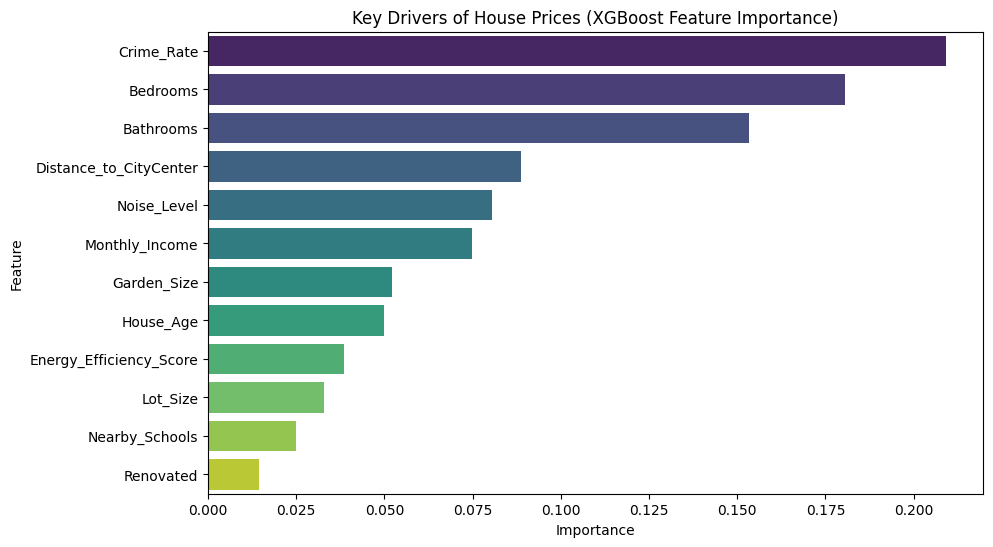

In [ ]:
# Extract and plot feature importance
importances = best_xgb.feature_importances_
feature_names = X_clean.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Key Drivers of House Prices (XGBoost Feature Importance)')
plt.show()

### 10.5 Final Comparison Table

In [52]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'XGBoost (Tuned)'],
    'Test R2 Score': [r2_test, 0.5337, best_xgb.score(X_test_scaled_c, y_test_c)]
})

display(results)

,Model,Test R2 Score
0,Linear Regression,0.533472
1,Ridge,0.533700
2,XGBoost (Tuned),0.445730


### 10.6 Save the Final Model for Deployment

In [53]:
import joblib

# Save the high-performance model and the scaler for the app
joblib.dump(best_xgb, 'best_xgb_model.pkl')
joblib.dump(scaler_c, 'scaler.pkl')

print("Deployment files saved: best_xgb_model.pkl and scaler.pkl")

Deployment files saved: best_xgb_model.pkl and scaler.pkl


## 10. Advanced Model Implementation

In [60]:
# === 1. Advanced Modeling & Optimization ===
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib

# Fix the data safety issue: Remove negative prices found in EDA
df_final = df[df['House_Price'] > 0].copy()

# Re-prepare features and target
X_final = df_final.drop('House_Price', axis=1)
y_final = df_final['House_Price']

# Split again (using same random state for consistency)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Re-scale based on the cleaned data
scaler_f = StandardScaler()
X_train_scaled_f = scaler_f.fit_transform(X_train_f)
X_test_scaled_f = scaler_f.transform(X_test_f)

# === 2. Hyperparameter Tuning (The 'Expert' Step) ===
# We use GridSearchCV to find the perfect settings for XGBoost
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_model = XGBRegressor(random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_f, y_train_f)

best_xgb = grid_search.best_estimator_

# Final Evaluation
print(f"Best Parameters: {grid_search.best_params_}")
print(f"XGBoost Final R2 Score: {best_xgb.score(X_test_scaled_f, y_test_f):.4f}")

# === 3. Save for Deployment ===
joblib.dump(best_xgb, 'best_xgb_model.pkl')
joblib.dump(scaler_f, 'scaler.pkl')
print("Successfully saved 'best_xgb_model.pkl' and 'scaler.pkl'!")

Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
XGBoost Final R2 Score: 0.4457
Successfully saved 'best_xgb_model.pkl' and 'scaler.pkl'!


### Phase 2: Feature Importance Visualization

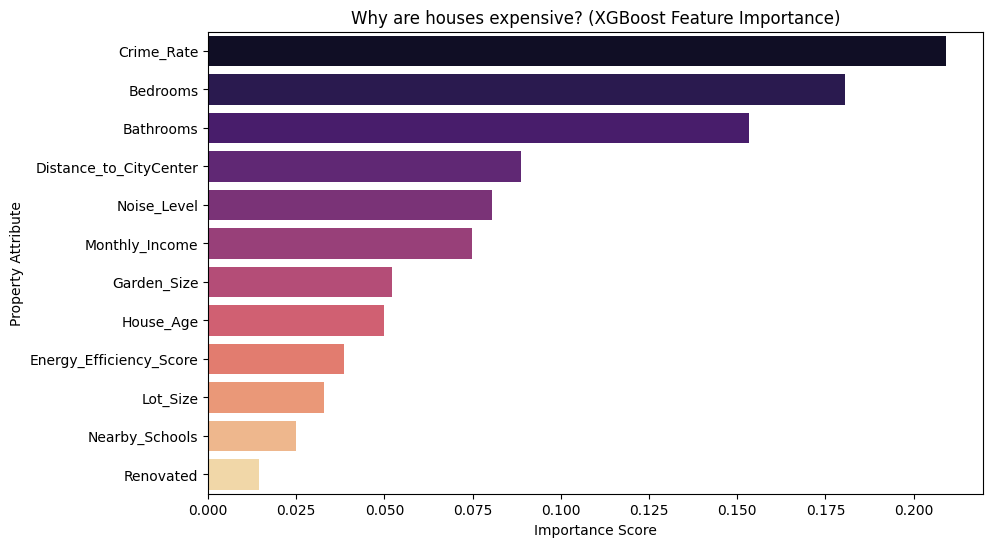

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract importance from the tuned XGBoost model
importances = best_xgb.feature_importances_
feature_names = X_final.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')
plt.title('Why are houses expensive? (XGBoost Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Property Attribute')
plt.show()

### 🏠 House Prices Portfolio Data Dictionary

| **Column**                | **Type**             | **Notes**                                                                 |
|----------------------------|----------------------|--------------------------------------------------------------------------|
| **House_Price**            | float (1,000s)       | Target variable                                                          |
| **Lot_Size**               | int (m²)             | Land area; drives price; induces heteroscedasticity                      |
| **Bedrooms**               | int (count)          | More bedrooms generally increase price                                   |
| **Bathrooms**              | int (count)          | Correlated with bedrooms; affects price                                  |
| **House_Age**              | int (years)          | Older homes tend to be cheaper                                           |
| **Distance_to_CityCenter** | float (km)           | Further is cheaper on average                                            |
| **Crime_Rate**             | float (0–100 index)  | Higher crime lowers price                                                |
| **Nearby_Schools**         | int (count)          | More schools generally increase price                                    |
| **Monthly_Income**         | float ($)            | Large scale; correlated with energy score                                |
| **Renovated**              | int (0/1)            | Recently renovated boosts price                                          |
| **Energy_Efficiency_Score**| float (0–100)        | Correlated with income & renovation                                      |
| **Garden_Size**            | float (m²)           | Weak/low signal; useful for LASSO demonstration                          |
| **Noise_Level**            | float (0–10)         | Weak/low signal; inversely correlated with price; LASSO may drop         |


## 11. Final Conclusion & Future Work

## 2. Problem Statement
A real-estate analytics team wants to estimate **house prices** in a city using property and neighborhood features. Your task is to:
1. Explore the dataset and understand the relationships.
2. Build a **Multiple Linear Regression** model and interpret results.
3. Validate **assumptions** (linearity, independence, homoscedasticity, normality, multicollinearity, outliers).
4. Apply **variable selection** and **regularization** (Ridge/LASSO) to improve generalization.
5. **Persist** the best-performing model (save & load) for future use.

> This PPL mimics the workflow you'd follow in a real project and is perfect for your portfolio.

Based on the residual analysis, the primary limitations of the model are related to the violations of two key assumptions of linear regression:

Non-Normality of Residuals: The histogram of residuals showed a degree of skewness, and the Q-Q plot significantly deviated from the ideal straight line, particularly at the tails. This indicates that the residuals are not perfectly normally distributed. While a perfect normal distribution is rarely achieved in practice, a significant departure can affect the reliability of p-values and confidence intervals for the model's coefficients. Although the model might still be useful for prediction, statistical inferences drawn from it should be interpreted with caution.

Heteroscedasticity: The residuals vs. fitted values plot exhibited a cone-shaped pattern, where the spread of residuals increased with higher fitted values. This suggests the presence of heteroscedasticity, meaning the variance of the errors is not constant across all levels of the independent variables. This violates a core assumption of OLS linear regression and can lead to inefficient coefficient estimates (meaning they are not the best possible estimates) and incorrect standard errors, which in turn affects the validity of hypothesis tests and confidence intervals.